In [1]:
import polars as pl

import pymovements as pm

In [2]:
dataset = pm.Dataset('ToyDataset', path='data/ToyDataset')
dataset.download()


Using already downloaded and verified file: data\ToyDataset\downloads\pymovements-toy-dataset.zip
Extracting pymovements-toy-dataset.zip to data\ToyDataset\raw


Archive files are automatically extracted into the path specified by Dataset.paths.raw:

In [3]:
dataset.paths.raw


WindowsPath('data/ToyDataset/raw')

Loading in your data into memory
Next we load our dataset into memory to be able to work with it:

In [4]:
dataset.load()


  0%|          | 0/20 [00:00<?, ?it/s]

In [5]:
dataset.fileinfo.head()


text_id,page_id,filepath
i64,i64,str
0,1,"""aeye-lab-pymov…"
0,2,"""aeye-lab-pymov…"
0,3,"""aeye-lab-pymov…"
0,4,"""aeye-lab-pymov…"
0,5,"""aeye-lab-pymov…"


We notice that for each filepath a text_id and page_id is specified.

We have also loaded our gaze data into the dataframes in the gaze attribute:

In [31]:
dataset.gaze[0].frame.head()

time,stimuli_x,stimuli_y,pixel,position,velocity,text_id,page_id
f32,f32,f32,list[f32],list[f32],list[f32],i64,i64
1.988145e6,-1.0,-1.0,"[206.800003, 152.399994]","[-10.697598, -8.8524]","[1.207726, -3.119128]",0,1
1.988146e6,-1.0,-1.0,"[206.899994, 152.100006]","[-10.695184, -8.859677]","[1.207692, -4.072155]",0,1
1.988147e6,-1.0,-1.0,"[207.0, 151.800003]","[-10.692768, -8.866956]","[1.035145, -4.765306]",0,1
1.988148e6,-1.0,-1.0,"[207.100006, 151.699997]","[-10.690351, -8.869382]","[1.207726, -4.245451]",0,1
1.988149e6,-1.0,-1.0,"[207.0, 151.5]","[-10.692768, -8.874233]","[1.552888, -2.339397]",0,1


Apart from some trial identifier columns we see the columns time and pixel.

The last two columns refer to the pixel coordinates at the timestep specified by time.

We are also able to just take a subset of the data by specifying values of the fileinfo columns. The key refers to the column in the fileinfo dataframe. The values in the dictionary can be of type bool, int, float or str, but also lists and ranges

In [7]:

subset = {
    'text_id': 0,
    'page_id': [0, 1],
}
dataset.load(subset=subset)

dataset.fileinfo

  0%|          | 0/1 [00:00<?, ?it/s]

text_id,page_id,filepath
i64,i64,str
0,1,"""aeye-lab-pymov…"


In [8]:
dataset.pix2deg()

dataset.gaze[0]

  0%|          | 0/1 [00:00<?, ?it/s]

In [9]:
dataset.pos2vel(method='savitzky_golay', degree=2, window_length=7)

dataset.gaze[0]

  0%|          | 0/1 [00:00<?, ?it/s]

## Detecting events
Now let's detect some events.

First we will detect fixations using the I-VT algorithm using its default parameters:

In [10]:

dataset.detect_events('ivt')

dataset.events[0]
     

0it [00:00, ?it/s]

In [13]:
display(dataset.events[0])

Next we detect some saccades. This time we don't use the default parameters but specify our own:

In [14]:
dataset.detect_events('microsaccades', minimum_duration=8)

dataset.events[0].frame.filter(pl.col('name') == 'saccade').head()
     

0it [00:00, ?it/s]

text_id,page_id,name,onset,offset,duration
i64,i64,str,i64,i64,i64
0,1,"""saccade""",1988323,1988337,14
0,1,"""saccade""",1988341,1988351,10
0,1,"""saccade""",1988546,1988567,21
0,1,"""saccade""",1988570,1988583,13
0,1,"""saccade""",1988736,1988760,24


In [16]:
# We can also use the more general interface of the apply() method:


dataset.apply('idt', dispersion_threshold=2.7, name='fixation.ivt')

dataset.events[0].frame.filter(pl.col('name') == 'fixation.ivt').head()

  0%|          | 0/1 [00:00<?, ?it/s]

text_id,page_id,name,onset,offset,duration
i64,i64,str,i64,i64,i64
0,1,"""fixation.ivt""",1988145,1988563,418
0,1,"""fixation.ivt""",1988564,1988750,186
0,1,"""fixation.ivt""",1988751,1989178,427
0,1,"""fixation.ivt""",1989179,1989436,257
0,1,"""fixation.ivt""",1989437,1989600,163


## Computing event properties
The event dataframe currently only holds the 'name', 'onset', 'offset' and 'duration' of an event (additionally we have some more identifier columns at the beginning).

We now want to compute some additional properties for each event. Event properties are things like peak velocity, amplitude and dispersion during an event.

We start out with computing the dispersion:

In [17]:

dataset.compute_event_properties("dispersion")

dataset.events[0]
# We notice that a new column with the name dispersion has appeared in the event dataframe.

# We can also pass a list of properties to compute all of our desired properties in a single run. Let's add the amplitude and peak velocity:

0it [00:00, ?it/s]

In [0]:

dataset.compute_event_properties(["amplitude", "peak_velocity"])

In [19]:

print(dataset.events[0])

## Plotting our data
pymovements provides a range of plotting functions.

You can browse through the available plotting functions here: Plotting

In this this tutorial we will plot the saccadic main sequence of our data.

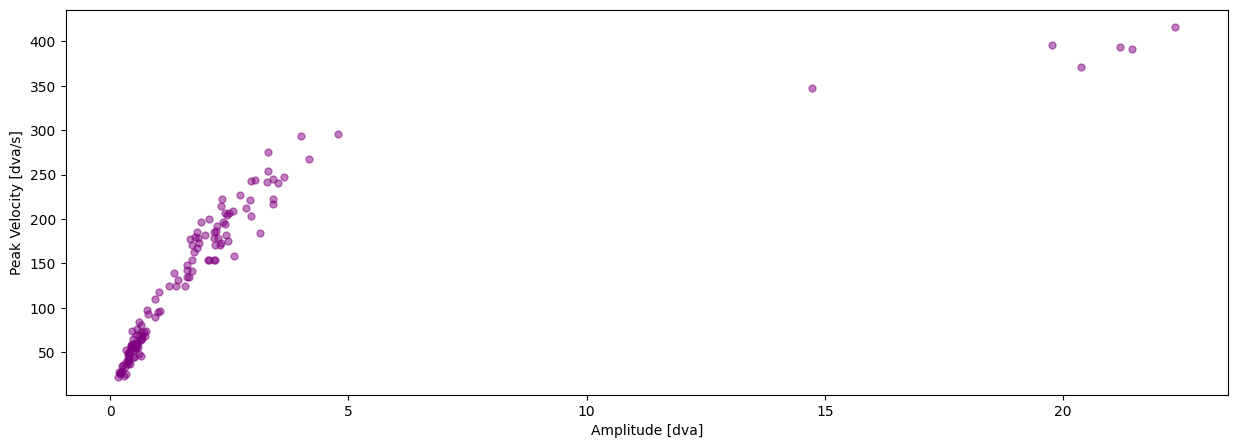

In [20]:
pm.plotting.main_sequence_plot(dataset.events[0])


## Saving and loading your dataframes
If we want to save interim results we can simply use the save() method like this:


In [21]:
dataset.save()

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Let's test this out by initializing a new PublicDataset object in the same directory and loading in the preprocessed gaze and event data.

This time we don't need to download anything.


In [22]:
preprocessed_dataset = pm.Dataset('ToyDataset', path='data/ToyDataset')

dataset.load(events=True, preprocessed=True, subset=subset)

display(dataset.gaze[0])
display(dataset.events[0])

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

In [29]:
dataset.events